# UCI HAR SSL
레이블이 적은 상황에도 HAR 모델을 잘 학습시킬 수 있을까?에 대해 SSL의 여러 방식으로 실험 해본 코드

실험 조건: 같은 데이터, 같은 모델, 레이블 10%만 사용
1. Supervised: SSL과 비교를 위해 레이블 10%만 사용하여 학습
2. Pseudo-Labeling: 모델이 자기 예측을 스스로 학습에 활용
3. FixMatch: 같은 데이터를 약하게/강하게 증강했을 때 예측이 일치하도록 학습



In [20]:
!pip install thop -q

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.manifold import TSNE
from thop import profile, clever_format

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 장치: {device}')

사용 장치: cuda


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
DATASET_PATH = "/content/drive/MyDrive/UCI HAR Dataset/"
TRAIN = "train/"
TEST  = "test/"

INPUT_SIGNAL_TYPES = [
    "body_acc_x_", "body_acc_y_", "body_acc_z_",
    "body_gyro_x_", "body_gyro_y_", "body_gyro_z_",
    "total_acc_x_", "total_acc_y_", "total_acc_z_"
]

LABELS = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING"
]

In [23]:
def load_X(X_signals_paths):
    X_signals = []
    for path in X_signals_paths:
        signal_data = []
        with open(path, 'r') as f:
            for row in f:
                row = row.replace('  ', ' ').strip().split(' ')
                signal_data.append([np.float32(x) for x in row])
        X_signals.append(signal_data)
    return np.transpose(np.array(X_signals), (1, 2, 0))  # (samples, 128, 9)

In [24]:
def load_y(y_path):
    with open(y_path, 'r') as f:
        y = [int(row.strip()) for row in f]
    return np.array(y, dtype=np.int64) - 1  # 1~6 → 0~5

In [25]:
X_train_paths = [DATASET_PATH + TRAIN + "Inertial Signals/" + s + "train.txt" for s in INPUT_SIGNAL_TYPES]
X_test_paths  = [DATASET_PATH + TEST  + "Inertial Signals/" + s + "test.txt"  for s in INPUT_SIGNAL_TYPES]

X_train = load_X(X_train_paths)
X_test  = load_X(X_test_paths)
y_train = load_y(DATASET_PATH + TRAIN + "y_train.txt")
y_test  = load_y(DATASET_PATH + TEST  + "y_test.txt")

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (7352, 128, 9) X_test: (2947, 128, 9)


In [26]:
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1),  keepdims=True) + 1e-8

X_train = ((X_train - mean) / std).astype(np.float32)
X_test  = ((X_test  - mean) / std).astype(np.float32)

print("표준화 완료")

표준화 완료


In [27]:
LABELED_RATIO = 0.10

rng           = np.random.RandomState(42)
indices       = rng.permutation(len(y_train))
n_labeled     = int(len(y_train) * LABELED_RATIO)
labeled_idx   = indices[:n_labeled]
unlabeled_idx = indices[n_labeled:]

X_labeled   = X_train[labeled_idx]
y_labeled   = y_train[labeled_idx]
X_unlabeled = X_train[unlabeled_idx]

print(f"레이블: {len(labeled_idx)} | 언레이블: {len(unlabeled_idx)}")

레이블: 735 | 언레이블: 6617


---
## 모델 정의

> PyTorch Conv1d 입력 형태: `(batch, channels, length)`  
> 원본 데이터 `(batch, 128, 9)` → `permute(0,2,1)` → `(batch, 9, 128)`

In [28]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=True):
        super().__init__()
        pad = kernel_size // 2
        self.shortcut = (
            nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, bias=False), nn.BatchNorm1d(out_ch))
            if in_ch != out_ch else nn.Identity()
        )
        self.conv1 = nn.Conv1d(in_ch,  out_ch, kernel_size, padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.pool  = nn.MaxPool1d(2) if pool else nn.Identity()

    def forward(self, x):
        s = self.shortcut(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return self.pool(F.relu(x + s))


class HARModel(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        # Multi-scale stem
        self.b1 = nn.Conv1d(9, 64, 3, padding=1, bias=False)
        self.b2 = nn.Conv1d(9, 64, 5, padding=2, bias=False)
        self.b3 = nn.Conv1d(9, 64, 7, padding=3, bias=False)
        self.bn_stem = nn.BatchNorm1d(192)
        # Residual blocks
        self.res1 = ResidualBlock(192, 128, 3, pool=True)
        self.res2 = ResidualBlock(128, 256, 3, pool=True)
        self.res3 = ResidualBlock(256, 256, 5, pool=False)
        self.res4 = ResidualBlock(256, 512, 3, pool=False)
        # Classifier
        self.fc1   = nn.Linear(1024, 256)
        self.drop1 = nn.Dropout(0.4)
        self.fc2   = nn.Linear(256, 128)
        self.drop2 = nn.Dropout(0.2)
        self.fc3   = nn.Linear(128, num_classes)

    def _backbone(self, x, noise=False):
        """(B,128,9) → (B,1024)"""
        x = x.permute(0, 2, 1)                                  # (B,9,128)
        if noise and self.training:
            x = x + torch.randn_like(x) * 0.01
        b1, b2, b3 = self.b1(x), self.b2(x), self.b3(x)
        x = F.relu(self.bn_stem(torch.cat([b1, b2, b3], dim=1)))
        x = self.res4(self.res3(self.res2(self.res1(x))))
        return torch.cat([x.mean(2), x.max(2).values], dim=1)   # GAP + GMP

    def get_features(self, x):
        """T-SNE용: Dense(128) 출력"""
        x = self._backbone(x)
        return F.relu(self.fc2(F.relu(self.fc1(x))))

    def forward(self, x, noise=False):
        x = self._backbone(x, noise=noise)
        x = self.drop1(F.relu(self.fc1(x)))
        x = self.drop2(F.relu(self.fc2(x)))
        return self.fc3(x)


# 파라미터 수 확인
_tmp = HARModel()
print(f"파라미터 수: {sum(p.numel() for p in _tmp.parameters()):,}")
del _tmp

파라미터 수: 2,752,710


##데이터 증강 방식
###weak_augment
- 가우시안 노이즈: 원본 신호값에 아주 작은 랜덤 노이즈를 부여하는 방식

특징: 원본과 거의 비슷하기 때문에 수도 라벨 생성에 사용

###strong_augment
- 큰 노이즈: 원본 신호값에 가우시안 노이즈보다 더 큰 노이즈를 부여하는 방식
- 스케일 변환: 원본 신호에 랜덤 배수를 곱하는 방식

특징: 원본과 많이 달라지기 때문에 같은 데이터라면 어떻게 변형해도 같은 답이 나오도록 학습

In [29]:
def weak_augment(X):
    return X + np.random.normal(0, 0.05, X.shape).astype(np.float32)

def strong_augment(X):
    noise = np.random.normal(0, 0.15, X.shape).astype(np.float32)
    scale = np.random.uniform(0.8, 1.2, (X.shape[0], 1, 1)).astype(np.float32)
    return (X + noise) * scale

In [30]:
# ── 예측 ──────────────────────────────────────────────────────
def get_preds(model, X, device, batch_size=256):
    model.eval()
    loader = DataLoader(TensorDataset(torch.FloatTensor(X)), batch_size=batch_size)
    preds  = []
    with torch.no_grad():
        for (X_b,) in loader:
            preds.append(model(X_b.to(device)).argmax(1).cpu().numpy())
    return np.concatenate(preds)


# ── T-SNE 특징 추출 ───────────────────────────────────────────
def get_features_all(model, X, device, batch_size=256):
    model.eval()
    loader = DataLoader(TensorDataset(torch.FloatTensor(X)), batch_size=batch_size)
    feats  = []
    with torch.no_grad():
        for (X_b,) in loader:
            feats.append(model.get_features(X_b.to(device)).cpu().numpy())
    return np.concatenate(feats)


# ── 모델 학습 ─────────────────────────────────────────────────
def train_model(model, X_l, y_l, device,
                epochs=100, batch_size=32, patience=20):
    dataset = TensorDataset(torch.FloatTensor(X_l), torch.LongTensor(y_l))
    n_val   = max(int(len(dataset) * 0.15), 1)
    train_ds, val_ds = random_split(
        dataset, [len(dataset) - n_val, n_val],
        generator=torch.Generator().manual_seed(42)
    )
    train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_ld   = DataLoader(val_ds,   batch_size=batch_size)

    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
    scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.3, patience=8, min_lr=1e-6)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.02)

    best_val_acc, best_state, pat_cnt = 0, None, 0

    for epoch in range(epochs):
        model.train()
        for X_b, y_b in train_ld:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(model(X_b, noise=True), y_b).backward()
            optimizer.step()

        model.eval()
        val_correct, val_loss = 0, 0.0
        with torch.no_grad():
            for X_b, y_b in val_ld:
                X_b, y_b = X_b.to(device), y_b.to(device)
                out = model(X_b)
                val_loss    += criterion(out, y_b).item()
                val_correct += (out.argmax(1) == y_b).sum().item()

        val_acc = val_correct / len(val_ds)
        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            pat_cnt = 0
        else:
            pat_cnt += 1

        if pat_cnt >= patience:
            break

    model.load_state_dict(best_state)
    return model

---
## Baseline: Supervised (레이블 10%만)

In [31]:
print("=" * 55)
print("[Baseline] Supervised — 레이블 10%만 사용")
print("=" * 55)

model_sup = HARModel().to(device)
model_sup = train_model(model_sup, X_labeled, y_labeled, device,
                        epochs=100, patience=20)

sup_acc = accuracy_score(y_test, get_preds(model_sup, X_test, device))
print(f"\n[Baseline] Test Accuracy: {sup_acc * 100:.2f}%")

[Baseline] Supervised — 레이블 10%만 사용

[Baseline] Test Accuracy: 92.26%


---
## SSL Method 1: Pseudo-Labeling

모델이 95% 이상 확신하는 샘플만 pseudo-label로 사용하면서 매 Iteration마다 늘어난 labeled data를 가지고 모델을 처음부터 다시 학습하는 방식으로 구성.



In [32]:
X_l_pl = X_labeled.copy()
y_l_pl = y_labeled.copy()
X_u_pl = X_unlabeled.copy()
pl_results = []

for it in range(5):
    print(f"\n─── Iteration {it+1} | 레이블: {len(X_l_pl)} | 언레이블: {len(X_u_pl)} ───")

    model_pl = HARModel().to(device)
    model_pl = train_model(model_pl, X_l_pl, y_l_pl, device,
                           epochs=80, patience=15)

    acc = accuracy_score(y_test, get_preds(model_pl, X_test, device))
    print(f"  Test Accuracy: {acc * 100:.2f}%")

    if len(X_u_pl) > 0:
        model_pl.eval()
        loader = DataLoader(TensorDataset(torch.FloatTensor(X_u_pl)), batch_size=256)
        probas = []
        with torch.no_grad():
            for (X_b,) in loader:
                p = torch.softmax(model_pl(X_b.to(device)), dim=1).cpu().numpy()
                probas.append(p)
        proba  = np.concatenate(probas)
        mask   = proba.max(axis=1) >= 0.95
        pseudo = proba.argmax(axis=1)
        print(f"  Pseudo-label 추가: {mask.sum()}개")
        if mask.sum() > 0:
            X_l_pl = np.concatenate([X_l_pl, X_u_pl[mask]])
            y_l_pl = np.concatenate([y_l_pl, pseudo[mask]])
            X_u_pl = X_u_pl[~mask]

    pl_results.append({'iter': it+1, 'n_labeled': len(X_l_pl), 'test_acc': acc})
    if len(X_u_pl) == 0:
        break

pl_final_acc = pl_results[-1]['test_acc']
print(f"\n[Pseudo-Labeling] 최종 Test Accuracy: {pl_final_acc * 100:.2f}%")


─── Iteration 1 | 레이블: 735 | 언레이블: 6617 ───
  Test Accuracy: 91.79%
  Pseudo-label 추가: 5085개

─── Iteration 2 | 레이블: 5820 | 언레이블: 1532 ───
  Test Accuracy: 92.67%
  Pseudo-label 추가: 373개

─── Iteration 3 | 레이블: 6193 | 언레이블: 1159 ───
  Test Accuracy: 93.59%
  Pseudo-label 추가: 501개

─── Iteration 4 | 레이블: 6694 | 언레이블: 658 ───
  Test Accuracy: 92.53%
  Pseudo-label 추가: 193개

─── Iteration 5 | 레이블: 6887 | 언레이블: 465 ───
  Test Accuracy: 93.01%
  Pseudo-label 추가: 233개

[Pseudo-Labeling] 최종 Test Accuracy: 93.01%


---
## SSL Method 2: FixMatch
원본 데이터에 약한 증강을 통해 예측한 라벨을 수도 라벨로 만들고 같은 샘플을 강하게 증강했을 때 그 class를 맞추도록 하는 방식으로 구성.

```
Loss = CE(레이블) + CE(강한증강, pseudo-label from 약한증강)
```

In [33]:
model_fm     = HARModel().to(device)
optimizer_fm = torch.optim.Adam(model_fm.parameters(), lr=3e-4)
ce_sup       = nn.CrossEntropyLoss(label_smoothing=0.02)
ce_unsup     = nn.CrossEntropyLoss(reduction='none')

THRESHOLD = 0.95
EPOCHS    = 200
BATCH     = 32

X_l_t = torch.FloatTensor(X_labeled).to(device)
y_l_t = torch.LongTensor(y_labeled).to(device)

best_fm_acc, best_fm_state = 0, None

for epoch in range(EPOCHS):
    model_fm.train()

    idx_l = np.random.choice(len(X_labeled),  BATCH,     replace=False)
    idx_u = np.random.choice(len(X_unlabeled), BATCH * 7, replace=False)

    X_l_b = X_l_t[idx_l]
    y_l_b = y_l_t[idx_l]
    X_u_w = torch.FloatTensor(weak_augment(X_unlabeled[idx_u])).to(device)
    X_u_s = torch.FloatTensor(strong_augment(X_unlabeled[idx_u])).to(device)

    optimizer_fm.zero_grad()

    # Supervised loss
    loss_s = ce_sup(model_fm(X_l_b, noise=True), y_l_b)

    # Pseudo-label from weak augmentation
    with torch.no_grad():
        pred_w = torch.softmax(model_fm(X_u_w), dim=1)
        conf, pseudo = pred_w.max(dim=1)
        mask = (conf >= THRESHOLD).float()

    # Consistency loss on strong augmentation
    pred_s = model_fm(X_u_s, noise=True)
    loss_u = (mask * ce_unsup(pred_s, pseudo)).mean()

    (loss_s + loss_u).backward()
    optimizer_fm.step()

    if (epoch + 1) % 10 == 0:
        acc = accuracy_score(y_test, get_preds(model_fm, X_test, device))
        if acc > best_fm_acc:
            best_fm_acc   = acc
            best_fm_state = {k: v.clone() for k, v in model_fm.state_dict().items()}
        print(f"Epoch {epoch+1:3d} | "
              f"loss={loss_s.item()+loss_u.item():.4f} | "
              f"acc={acc:.4f} (best={best_fm_acc:.4f})")

model_fm.load_state_dict(best_fm_state)
fm_final_acc = best_fm_acc
print(f"\n[FixMatch] 최종 Test Accuracy: {fm_final_acc * 100:.2f}%")

Epoch  10 | loss=1.0589 | acc=0.7190 (best=0.7190)
Epoch  20 | loss=0.4429 | acc=0.8694 (best=0.8694)
Epoch  30 | loss=0.4654 | acc=0.9108 (best=0.9108)
Epoch  40 | loss=0.3427 | acc=0.9230 (best=0.9230)
Epoch  50 | loss=0.1988 | acc=0.8999 (best=0.9230)
Epoch  60 | loss=0.4595 | acc=0.9257 (best=0.9257)
Epoch  70 | loss=0.1815 | acc=0.9111 (best=0.9257)
Epoch  80 | loss=0.3262 | acc=0.9169 (best=0.9257)
Epoch  90 | loss=0.2172 | acc=0.9053 (best=0.9257)
Epoch 100 | loss=0.2892 | acc=0.9206 (best=0.9257)
Epoch 110 | loss=0.2345 | acc=0.9237 (best=0.9257)
Epoch 120 | loss=0.4027 | acc=0.9284 (best=0.9284)
Epoch 130 | loss=0.3437 | acc=0.9179 (best=0.9284)
Epoch 140 | loss=0.2729 | acc=0.9125 (best=0.9284)
Epoch 150 | loss=0.5694 | acc=0.9206 (best=0.9284)
Epoch 160 | loss=0.2260 | acc=0.9335 (best=0.9335)
Epoch 170 | loss=0.4661 | acc=0.9257 (best=0.9335)
Epoch 180 | loss=0.3310 | acc=0.9274 (best=0.9335)
Epoch 190 | loss=0.2716 | acc=0.9097 (best=0.9335)
Epoch 200 | loss=0.2554 | acc=0

---
## 종합 평가
Accuracy / Precision / Recall / F1 / Parameters / FLOPs / 추론시간

In [34]:
def measure_inference_time(model, X, device, n_runs=5, batch_size=256):
    model.eval()
    loader = DataLoader(TensorDataset(torch.FloatTensor(X[:32])), batch_size=32)
    with torch.no_grad():  # warm-up
        for (X_b,) in loader:
            model(X_b.to(device))
    times = []
    full_loader = DataLoader(TensorDataset(torch.FloatTensor(X)), batch_size=batch_size)
    for _ in range(n_runs):
        t0 = time.time()
        with torch.no_grad():
            for (X_b,) in full_loader:
                model(X_b.to(device))
        times.append(time.time() - t0)
    avg_ms = np.mean(times) * 1000
    return avg_ms, avg_ms / len(X)


def evaluate_model(model, X_test, y_test, device, name):
    y_pred = get_preds(model, X_test, device)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec  = recall_score(y_test, y_pred, average='macro')
    f1   = f1_score(y_test, y_pred, average='macro')
    params = sum(p.numel() for p in model.parameters())

    try:
        dummy = torch.randn(1, 128, 9).to(device)
        flops, _ = profile(model, inputs=(dummy,), verbose=False)
    except Exception:
        flops = -1

    infer_ms, per_ms = measure_inference_time(model, X_test, device)

    return {
        'name': name, 'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'params': params,
        'flops': flops, 'infer_ms': infer_ms, 'per_ms': per_ms,
        'y_pred': y_pred
    }


results_all = [
    evaluate_model(model_sup, X_test, y_test, device, 'Supervised (10%)'),
    evaluate_model(model_pl,  X_test, y_test, device, 'Pseudo-Labeling'),
    evaluate_model(model_fm,  X_test, y_test, device, 'FixMatch'),
]

print(f"\n{'방법':<22} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} "
      f"{'Params':>10} {'FLOPs':>12} {'추론(ms)':>10} {'샘플당(ms)':>10}")
print("-" * 100)
for r in results_all:
    flops_str = f"{r['flops']:,.0f}" if r['flops'] > 0 else 'N/A'
    print(f"{r['name']:<22} {r['accuracy']:>7.4f} {r['precision']:>7.4f} "
          f"{r['recall']:>7.4f} {r['f1']:>7.4f} "
          f"{r['params']:>10,} {flops_str:>12} "
          f"{r['infer_ms']:>10.1f} {r['per_ms']:>10.3f}")


방법                         Acc    Prec  Recall      F1     Params        FLOPs     추론(ms)    샘플당(ms)
----------------------------------------------------------------------------------------------------
Supervised (10%)        0.9226  0.9246  0.9247  0.9244  2,752,710  104,915,712      241.5      0.082
Pseudo-Labeling         0.9301  0.9321  0.9323  0.9316  2,752,710  104,915,712      238.1      0.081
FixMatch                0.9335  0.9338  0.9351  0.9342  2,752,710  104,915,712      236.0      0.080


---
## Confusion Matrix

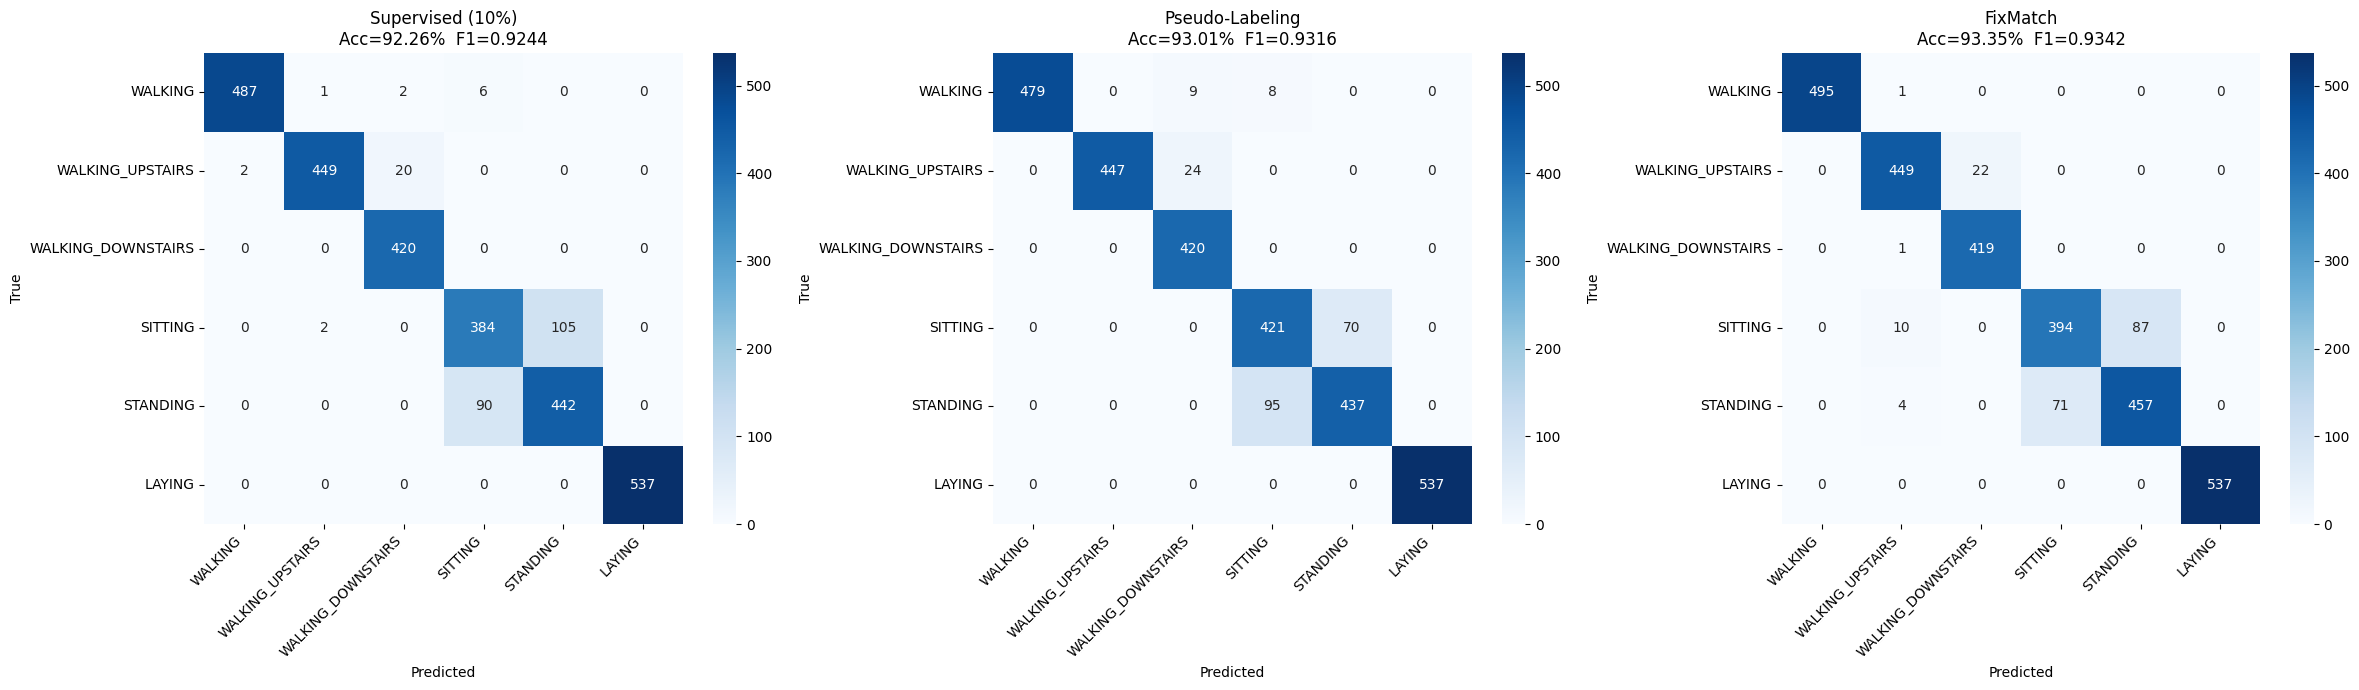

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, r in zip(axes, results_all):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(f"{r['name']}\nAcc={r['accuracy']*100:.2f}%  F1={r['f1']:.4f}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

---
## Classification Report (클래스별 상세)

In [36]:
for r in results_all:
    print(f"\n{'='*55}\n[{r['name']}]\n{'='*55}")
    print(classification_report(y_test, r['y_pred'], target_names=LABELS, digits=4))


[Supervised (10%)]
                    precision    recall  f1-score   support

           WALKING     0.9959    0.9819    0.9888       496
  WALKING_UPSTAIRS     0.9934    0.9533    0.9729       471
WALKING_DOWNSTAIRS     0.9502    1.0000    0.9745       420
           SITTING     0.8000    0.7821    0.7909       491
          STANDING     0.8080    0.8308    0.8193       532
            LAYING     1.0000    1.0000    1.0000       537

          accuracy                         0.9226      2947
         macro avg     0.9246    0.9247    0.9244      2947
      weighted avg     0.9232    0.9226    0.9227      2947


[Pseudo-Labeling]
                    precision    recall  f1-score   support

           WALKING     1.0000    0.9657    0.9826       496
  WALKING_UPSTAIRS     1.0000    0.9490    0.9739       471
WALKING_DOWNSTAIRS     0.9272    1.0000    0.9622       420
           SITTING     0.8034    0.8574    0.8296       491
          STANDING     0.8619    0.8214    0.8412       5

---
## T-SNE 시각화

Dense(128) 레이어 특징 벡터를 2D로 투영 — 클래스가 잘 분리될수록 좋은 표현 학습

T-SNE 계산 중: Supervised (10%) ...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


T-SNE 계산 중: Pseudo-Labeling ...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


T-SNE 계산 중: FixMatch ...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


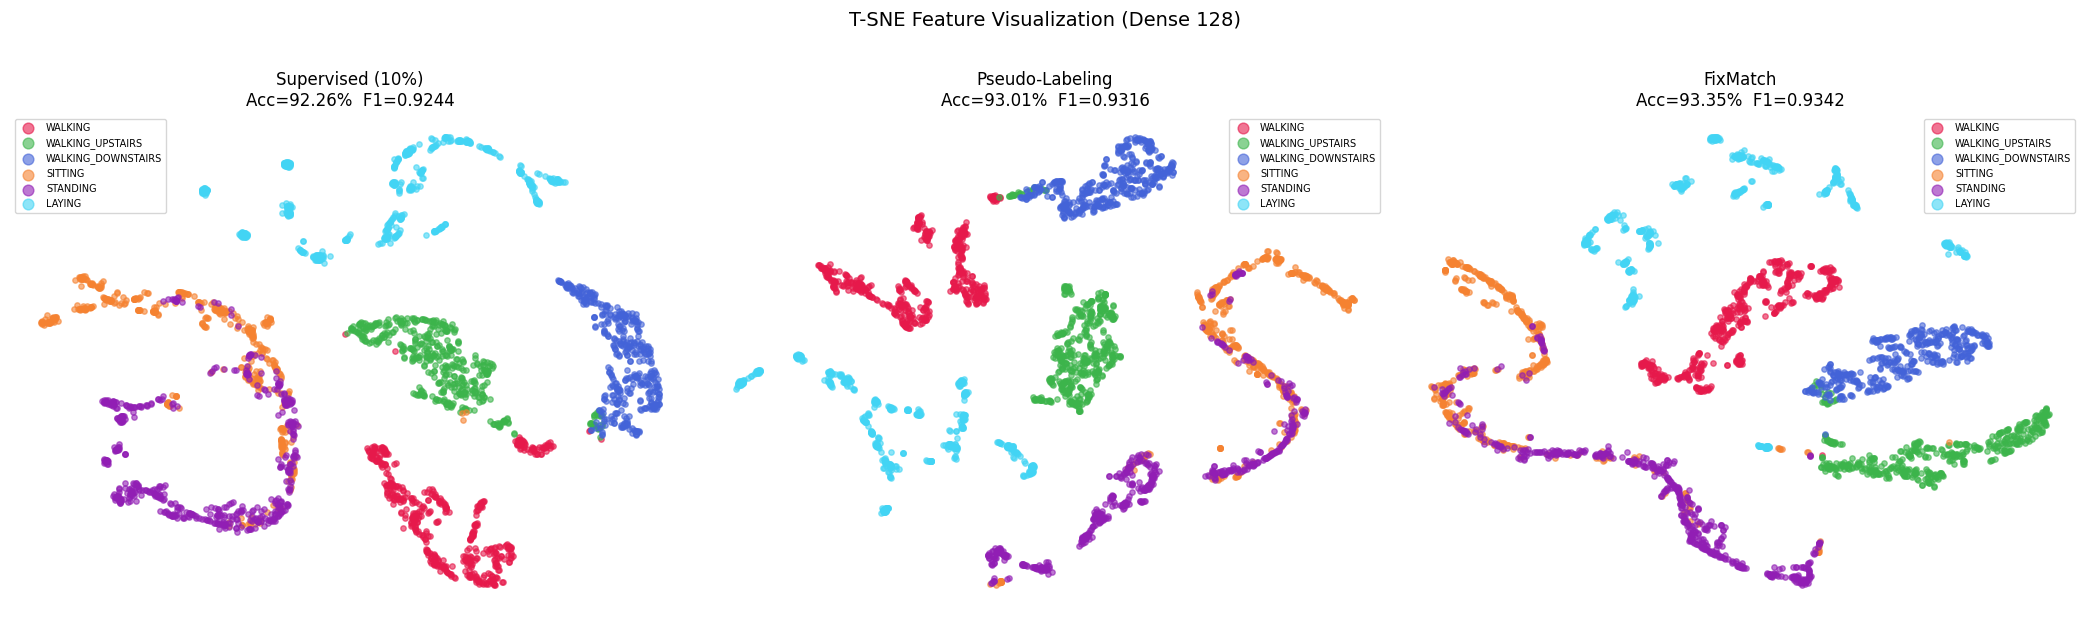

In [37]:
COLORS = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4','#42d4f4']

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (model, r) in zip(axes, [
    (model_sup, results_all[0]),
    (model_pl,  results_all[1]),
    (model_fm,  results_all[2]),
]):
    print(f"T-SNE 계산 중: {r['name']} ...")
    feats = get_features_all(model, X_test, device)
    emb   = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000).fit_transform(feats)

    for cls_idx, (label, color) in enumerate(zip(LABELS, COLORS)):
        mask = y_test == cls_idx
        ax.scatter(emb[mask, 0], emb[mask, 1], label=label, color=color, alpha=0.6, s=15)

    ax.set_title(f"{r['name']}\nAcc={r['accuracy']*100:.2f}%  F1={r['f1']:.4f}")
    ax.legend(fontsize=7, markerscale=2)
    ax.axis('off')

plt.suptitle('T-SNE Feature Visualization (Dense 128)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 최종 성능 비교 차트

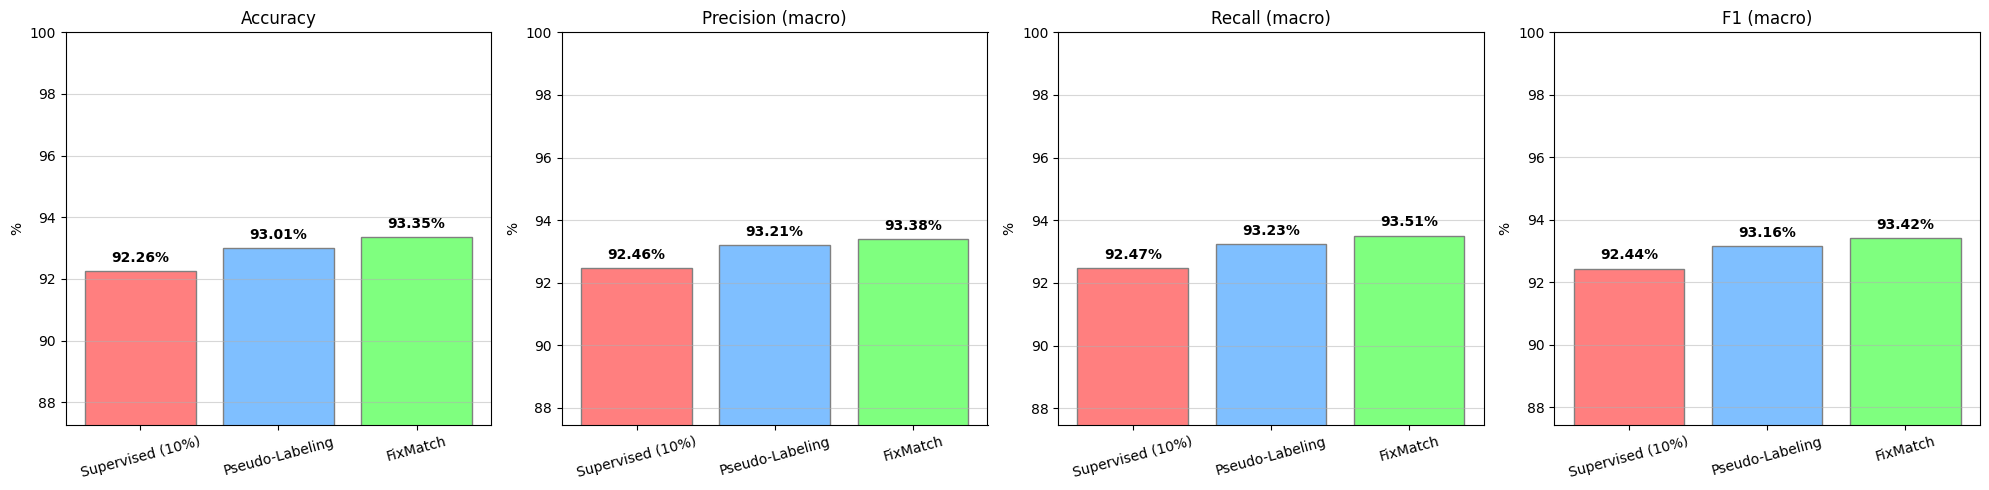

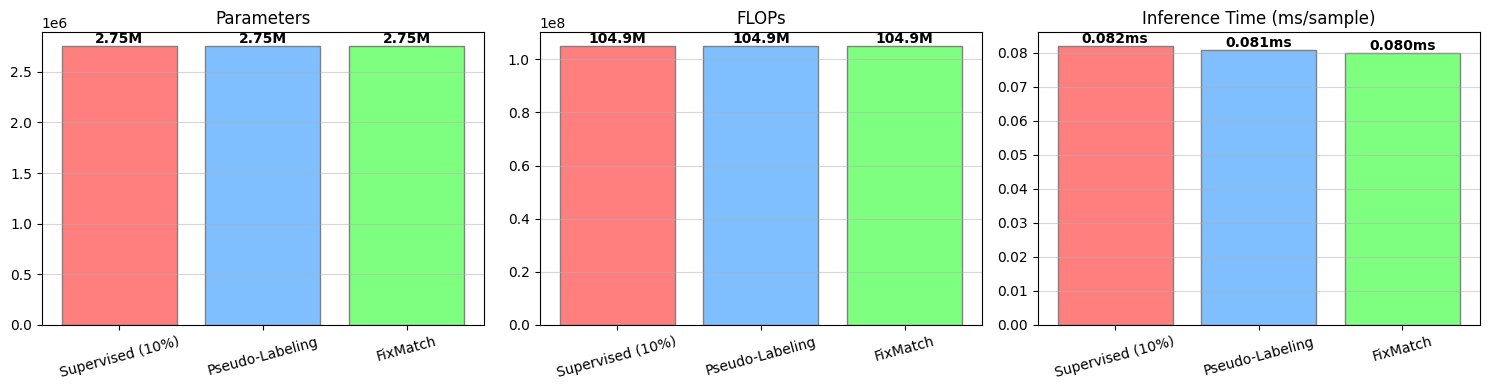

In [39]:
names  = [r['name'] for r in results_all]
colors = ['#ff7f7f', '#7fbfff', '#7fff7f']

# 성능 지표 비교
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (metric, title) in zip(axes, [
    ('accuracy',  'Accuracy'),
    ('precision', 'Precision (macro)'),
    ('recall',    'Recall (macro)'),
    ('f1',        'F1 (macro)'),
]):
    vals = [r[metric] * 100 for r in results_all]
    bars = ax.bar(names, vals, color=colors, edgecolor='gray')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.3,
                f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title); ax.set_ylabel('%')
    ax.set_ylim(min(vals)-5, 100)
    ax.tick_params(axis='x', rotation=15); ax.grid(True, axis='y', alpha=0.5)
plt.tight_layout(); plt.show()

# 효율성 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (key, title, fmt) in zip(axes, [
    ('params',  'Parameters',        lambda v: f'{v/1e6:.2f}M'),
    ('flops',   'FLOPs',             lambda v: f'{v/1e6:.1f}M' if v>0 else 'N/A'),
    ('per_ms',  'Inference Time (ms/sample)', lambda v: f'{v:.3f}ms'),
]):
    vals = [r[key] for r in results_all]
    bars = ax.bar(names, vals, color=colors, edgecolor='gray')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                fmt(val), ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15); ax.grid(True, axis='y', alpha=0.5)
plt.tight_layout(); plt.show()